In [86]:
import matplotlib.pyplot as plt
import numpy as np

In [87]:
# save to txt all data so that and then get the data from the txt file
#np.savetxt('DAC_IRPower_PD.txt', np.column_stack((V_DAC,P_mW,PD_mV)), header='#DAC_Voltage_V\tPower_mW\tPD_mV', fmt='%.3f', delimiter='\t')
DAC_V = np.loadtxt('DAC_IRPower_PD.txt', skiprows=1, usecols=0)
P_mW = np.loadtxt('DAC_IRPower_PD.txt', skiprows=1, usecols=1)
PD_mV = np.loadtxt('DAC_IRPower_PD.txt', skiprows=1, usecols=2)

In [95]:
# print as table
print('DAC_Voltage_V\tPower_mW\tPD_mV')
for v, p, pd in zip(DAC_V, P_mW, PD_mV):
    print(f'{v:.3f}\t\t{p:.3f}\t\t{pd:.3f}')

DAC_Voltage_V	Power_mW	PD_mV
0.100		2.580		18.150
0.200		4.480		18.700
0.300		6.800		19.050
0.400		9.300		19.850
0.500		11.650		20.450
0.600		13.800		20.930
0.700		15.400		21.750
0.800		19.000		22.380
1.000		23.700		23.400
1.500		35.400		26.700
2.000		46.000		29.500
2.500		58.000		32.700
3.000		68.000		35.800
3.500		80.000		38.900
4.000		91.000		42.000
4.100		95.000		44.000
4.150		108.000		48.700
4.200		150.000		59.500
4.250		205.000		70.800
4.300		278.000		91.000
4.400		392.000		119.500
4.500		512.000		150.200
4.600		648.000		181.000
4.700		780.000		212.000
4.800		910.000		241.000
4.900		1038.000		273.000
5.000		1170.000		298.400
5.200		1410.000		360.000
5.400		1670.000		421.000
5.600		1900.000		477.000
5.800		2180.000		543.000
6.000		2460.000		606.000
7.000		3770.000		908.000
8.000		5120.000		1248.000
8.200		5500.000		1360.000


Fit: PD_mV = 0.241 * P_mW + 19.888


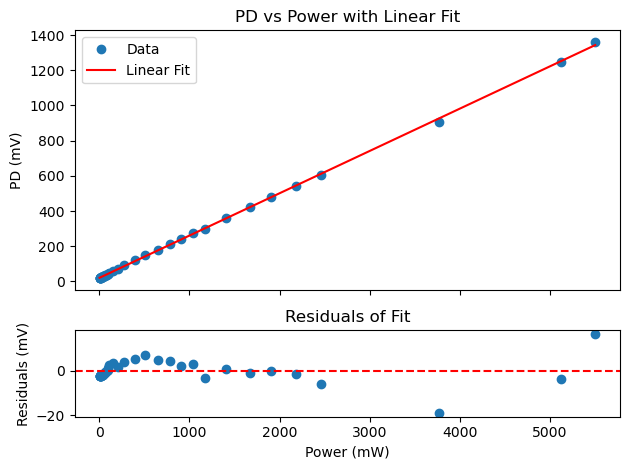

In [96]:
# plot PD vs P
# do linear fit
fit = np.polyfit(P_mW, PD_mV, 1)
print(f'Fit: PD_mV = {fit[0]:.3f} * P_mW + {fit[1]:.3f}')

# add residual plot
residuals = PD_mV - (fit[0] * P_mW + fit[1])
fig,ax = plt.subplots(2,1,sharex=True,gridspec_kw={'height_ratios':[3,1]})
ax[0].plot(P_mW, PD_mV, 'o', label='Data')
ax[0].plot(P_mW, fit[0] * P_mW + fit[1], 'r-', label='Linear Fit')
ax[0].set_ylabel('PD (mV)')
ax[0].legend()
ax[0].set_title('PD vs Power with Linear Fit')  
ax[1].plot(P_mW, residuals, 'o')
ax[1].axhline(0, color='r', linestyle='--')
ax[1].set_xlabel('Power (mW)')
ax[1].set_ylabel('Residuals (mV)')
ax[1].set_title('Residuals of Fit')
plt.tight_layout()
plt.show()


Fit for PD < 100 mV: PD_mV = 0.267 * P_mW + 17.556


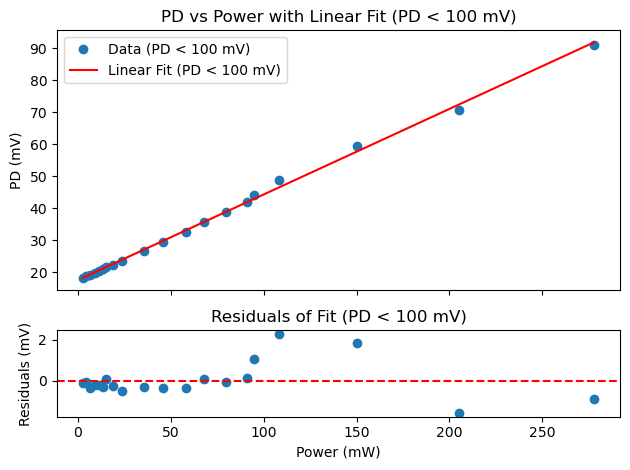

In [97]:
# same but for PD < 100
mask = PD_mV < 110
fit_low = np.polyfit(P_mW[mask], PD_mV[mask], 1)
print(f'Fit for PD < 100 mV: PD_mV = {fit_low[0]:.3f} * P_mW + {fit_low[1]:.3f}')
residuals_low = PD_mV[mask] - (fit_low[0] * P_mW[mask] + fit_low[1])
fig,ax = plt.subplots(2,1,sharex=True,gridspec_kw={'height_ratios':[3,1]})
ax[0].plot(P_mW[mask], PD_mV[mask], 'o', label='Data (PD < 100 mV)')
ax[0].plot(P_mW[mask], fit_low[0] * P_mW[mask] + fit_low[1], 'r-', label='Linear Fit (PD < 100 mV)')
ax[0].set_ylabel('PD (mV)')
ax[0].legend()
ax[0].set_title('PD vs Power with Linear Fit (PD < 100 mV)')  
ax[1].plot(P_mW[mask], residuals_low, 'o')
ax[1].axhline(0, color='r', linestyle='--')
ax[1].set_xlabel('Power (mW)')
ax[1].set_ylabel('Residuals (mV)')
ax[1].set_title('Residuals of Fit (PD < 100 mV)')
plt.tight_layout()
plt.show()

Fit for P > 100 mW: PD_mV = 0.240 * P_mW + 22.338


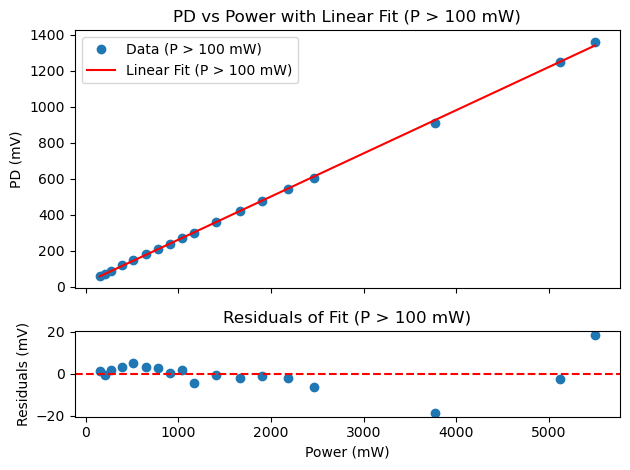

In [105]:
# same for P > 100 mW
mask_high = P_mW > 110
fit_high = np.polyfit(P_mW[mask_high], PD_mV[mask_high], 1)
print(f'Fit for P > 100 mW: PD_mV = {fit_high[0]:.3f} * P_mW + {fit_high[1]:.3f}')
residuals_high = PD_mV[mask_high] - (fit_high[0] * P_mW[mask_high] + fit_high[1])
fig,ax = plt.subplots(2,1,sharex=True,gridspec_kw={'height_ratios':[3,1]})
ax[0].plot(P_mW[mask_high], PD_mV[mask_high], 'o', label='Data (P > 100 mW)')
ax[0].plot(P_mW[mask_high], fit_high[0] * P_mW[mask_high] + fit_high[1], 'r-', label='Linear Fit (P > 100 mW)')
ax[0].set_ylabel('PD (mV)')
ax[0].legend()
ax[0].set_title('PD vs Power with Linear Fit (P > 100 mW)')  
ax[1].plot(P_mW[mask_high], residuals_high, 'o')
ax[1].axhline(0, color='r', linestyle='--')
ax[1].set_xlabel('Power (mW)')
ax[1].set_ylabel('Residuals (mV)')
ax[1].set_title('Residuals of Fit (P > 100 mW)')
plt.tight_layout()
#plt.xlim(0,1000)
plt.show()

In [ ]:
def get_VPD_from_P(P_mW):
    return 0.240 * P_mW + 17.5

In [ ]:
def get_P_from_VPD(V_PD):
    return (V_PD - 17.5) / 0.240

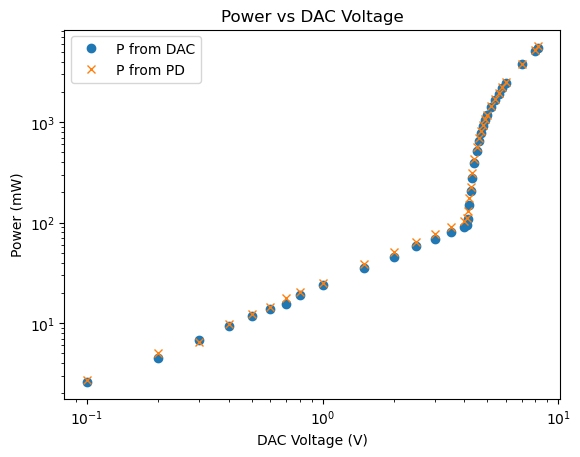

In [102]:
P_mW_from_VPD = get_P_from_VPD(PD_mV)
# plot P as a function of V_DAC
plt.figure()
plt.plot(DAC_V, P_mW, 'o', label='P from DAC')
plt.plot(DAC_V, P_mW_from_VPD, 'x', label='P from PD')
plt.xlabel('DAC Voltage (V)')
plt.ylabel('Power (mW)')
plt.title('Power vs DAC Voltage')
plt.loglog()
plt.legend()
plt.show()

In [104]:
# save this P_from_VPD and V_DAC to a txt file, first P and then V_DAC
np.savetxt('P_from_VPD.txt', np.column_stack((P_mW_from_VPD,DAC_V)), header='#DAC_Voltage_V\tPower_from_VPD_mW', fmt='%.3f', delimiter='\t')